In [3]:
import pandas as pd

df = pd.read_excel(r"C:\Users\Asus\Downloads\Fitness_App_User_Data.xlsx")
print(df.head())

   User_ID  Age  Gender  Workouts_per_Week  Avg_Session_Duration_Min  \
0        1   56    Male                  1                      27.7   
1        2   46  Female                  6                      68.6   
2        3   32  Female                  5                      28.1   
3        4   25    Male                  6                      64.2   
4        5   38  Female                  1                      44.6   

   Steps_per_Day Subscription_Type  Churned  
0           2055              Free        1  
1          10717              Free        0  
2          14761              Free        0  
3          14315              Free        0  
4          10150              Free        0  


In [4]:
# Check missing values in each column
print(df.isnull().sum())

User_ID                     0
Age                         0
Gender                      0
Workouts_per_Week           0
Avg_Session_Duration_Min    0
Steps_per_Day               0
Subscription_Type           0
Churned                     0
dtype: int64


In [5]:

# Count duplicate rows
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [6]:
# Remove duplicates
df = df.drop_duplicates()

print("New shape:", df.shape)

New shape: (200, 8)


In [7]:
print("Remaining duplicate rows:", df.duplicated().sum())

Remaining duplicate rows: 0


In [8]:
# Check current data types
print(df.dtypes)

# Remove extra spaces in column names
df.columns = df.columns.str.strip()

# Correct numeric columns
numeric_cols = [
    "User_ID",
    "Age",
    "Workouts_per_Week",
    "Avg_Session_Duration_Min",
    "Steps_per_Day",
    "Churned"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Correct text columns
text_cols = ["Gender", "Subscription_Type"]

for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

# Fix common inconsistencies
df["Gender"] = df["Gender"].replace({
    "M": "Male",
    "F": "Female",
    "male": "Male",
    "female": "Female"
})

df["Subscription_Type"] = df["Subscription_Type"].replace({
    "free": "Free",
    "premium": "Premium"
})

# Convert Churned to integer category
df["Churned"] = df["Churned"].astype("int64")

# Check final data types
print(df.dtypes)

# Check unique values
print(df["Gender"].unique())
print(df["Subscription_Type"].unique())
print(df["Churned"].unique())

User_ID                       int64
Age                           int64
Gender                       object
Workouts_per_Week             int64
Avg_Session_Duration_Min    float64
Steps_per_Day                 int64
Subscription_Type            object
Churned                       int64
dtype: object
User_ID                       int64
Age                           int64
Gender                       object
Workouts_per_Week             int64
Avg_Session_Duration_Min    float64
Steps_per_Day                 int64
Subscription_Type            object
Churned                       int64
dtype: object
['Male' 'Female']
['Free' 'Premium']
[1 0]


In [9]:
features = [
    "Age",
    "Workouts_per_Week",
    "Avg_Session_Duration_Min",
    "Steps_per_Day"
]

In [11]:
df = pd.read_excel(r"C:\Users\Asus\Downloads\Fitness_App_User_Data.xlsx")

X = df[[
    "Age",
    "Workouts_per_Week",
    "Avg_Session_Duration_Min",
    "Steps_per_Day"
]]

print(X.head())

   Age  Workouts_per_Week  Avg_Session_Duration_Min  Steps_per_Day
0   56                  1                      27.7           2055
1   46                  6                      68.6          10717
2   32                  5                      28.1          14761
3   25                  6                      64.2          14315
4   38                  1                      44.6          10150


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [18]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_excel(r"C:\Users\Asus\Downloads\Fitness_App_User_Data.xlsx")

X = df[[
    "Age",
    "Workouts_per_Week",
    "Avg_Session_Duration_Min",
    "Steps_per_Day"
]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)
print(df[["User_ID", "Cluster"]].head())

print(df["Cluster"].value_counts())

cluster_summary = df.groupby("Cluster")[[
    "Age",
    "Workouts_per_Week",
    "Avg_Session_Duration_Min",
    "Steps_per_Day"
]].mean()

print(cluster_summary)


   User_ID  Cluster
0        1        1
1        2        2
2        3        2
3        4        2
4        5        0
Cluster
1    73
2    65
0    62
Name: count, dtype: int64
               Age  Workouts_per_Week  Avg_Session_Duration_Min  Steps_per_Day
Cluster                                                                       
0        47.709677           1.677419                 38.474194   11021.661290
1        34.095890           2.410959                 45.572603    4720.178082
2        35.169231           4.984615                 47.258462   10572.953846


c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


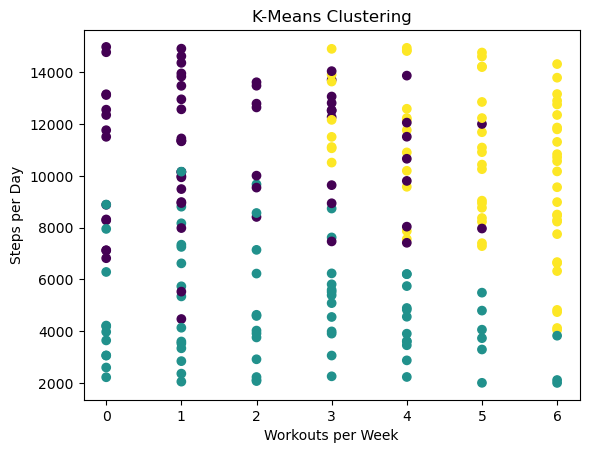

In [19]:
import matplotlib.pyplot as plt

plt.scatter(
    df["Workouts_per_Week"],
    df["Steps_per_Day"],
    c=df["Cluster"]
)

plt.xlabel("Workouts per Week")
plt.ylabel("Steps per Day")
plt.title("K-Means Clustering")
plt.show()

c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

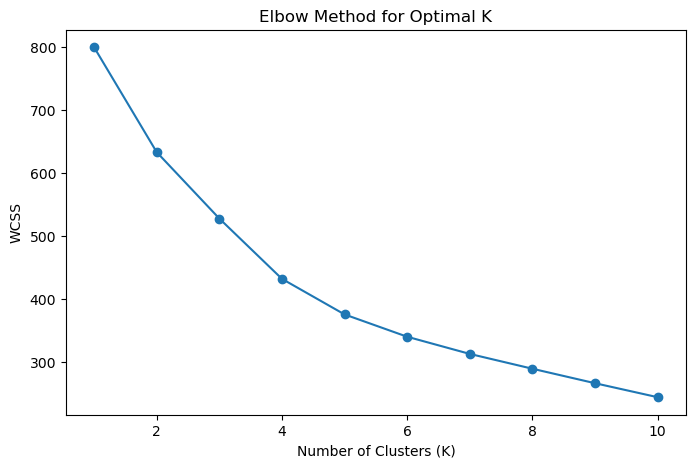

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_excel(r"C:\Users\Asus\Downloads\Fitness_App_User_Data.xlsx")

# Select features
X = df[[
    "Age",
    "Workouts_per_Week",
    "Avg_Session_Duration_Min",
    "Steps_per_Day"
]]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calculate WCSS
wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()



In [26]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X_scaled)

cluster_summary = df.groupby("Cluster")[[
    "Age",
    "Workouts_per_Week",
    "Avg_Session_Duration_Min",
    "Steps_per_Day"
]].mean()

print(cluster_summary)

               Age  Workouts_per_Week  Avg_Session_Duration_Min  Steps_per_Day
Cluster                                                                       
0        47.709677           1.677419                 38.474194   11021.661290
1        34.095890           2.410959                 45.572603    4720.178082
2        35.169231           4.984615                 47.258462   10572.953846


c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
